In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install librosa tensorflow numpy pandas scikit-learn matplotlib

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor

# MFCC Extraction Function
def extract_mfcc_2d(
    file_path,
    n_mfcc=40,
    segment_duration=3,
    overlap=0.5,
    n_fft=2048,
    hop_length=512
):
    audio, sr = librosa.load(file_path, sr=None)
    segment_samples = int(segment_duration * sr)
    step_samples = int(segment_samples * (1 - overlap))

    mfcc_features = []
    for start in range(0, len(audio) - segment_samples + 1, step_samples):
        segment = audio[start:start + segment_samples]
        mfcc = librosa.feature.mfcc(
            y=segment,
            sr=sr,
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            hop_length=hop_length
        )
        mfcc_features.append(mfcc.T)  # (time_steps, n_mfcc)

    return mfcc_features

BASE_PATH = "/content/drive/MyDrive/Data/genres_original"

file_metadata = []
for genre in os.listdir(BASE_PATH):
    genre_path = os.path.join(BASE_PATH, genre)
    if not os.path.isdir(genre_path):
        continue

    for fname in os.listdir(genre_path):
        if fname.endswith(".wav"):
            file_metadata.append({
                "filename": fname,
                "label": genre,
                "filepath": os.path.join(genre_path, fname)
            })

file_metadata = pd.DataFrame(file_metadata)
genres = sorted(file_metadata["label"].unique())

print("Total audio files:", len(file_metadata))  # 1000

train_meta, test_meta = train_test_split(
    file_metadata,
    test_size=0.2,
    stratify=file_metadata["label"],
    random_state=42
)

train_meta, val_meta = train_test_split(
    train_meta,
    test_size=0.2,
    stratify=train_meta["label"],
    random_state=42
)

# MFCC extraction AFTER splitting
def extract_split(df):
    X, y, file_names = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        mfcc_segments = extract_mfcc_2d(row["filepath"])
        X.extend(mfcc_segments)
        y.extend([row["label"]] * len(mfcc_segments))
        file_names.extend([row["filename"]] * len(mfcc_segments))

    return np.array(X), np.array(y), np.array(file_names)

X_train, y_train, fn_train = extract_split(train_meta)
X_val, y_val, fn_val     = extract_split(val_meta)
X_test, y_test, fn_test  = extract_split(test_meta)

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)

# LOF outlier detection (TRAIN ONLY)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
inlier_mask = lof.fit_predict(X_train_flat) == 1

X_train = X_train[inlier_mask]
y_train = y_train[inlier_mask]
fn_train = fn_train[inlier_mask]

print("Train shape after LOF:", X_train.shape)

Total audio files: 999


100%|██████████| 200/200 [04:02<00:00,  1.21s/it]


Train shape: (12137, 130, 40)
Val shape:   (3037, 130, 40)
Test shape:  (3798, 130, 40)
Train shape after LOF: (11530, 130, 40)


In [5]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

In [6]:
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(X_train.shape, X_val.shape, X_test.shape)

(11530, 130, 40, 1) (3037, 130, 40, 1) (3798, 130, 40, 1)


In [7]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, LSTM, Reshape
from tensorflow.keras.models import Model

def build_edl_model(input_shape, num_classes):
    inputs = Input(shape=(130, 40, 1))
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Reshape((x.shape[1], -1))(x)
    x = LSTM(64)(x)
    x = Dropout(0.5)(x)
    evidence = Dense(num_classes, activation='softplus')(x)
    return Model(inputs, outputs=evidence)

In [36]:
def build_ce_model(input_shape, num_classes):
    inputs = Input(shape=(130, 40, 1))
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Reshape((x.shape[1], -1))(x)
    x=LSTM(64)(x)
    x = Dropout(0.5)(x)
    logits = Dense(num_classes)(x)
    outputs = tf.keras.layers.Softmax()(logits)
    return Model(inputs, outputs)

In [9]:
def kl_dirichlet(alpha):
    num_classes = tf.shape(alpha)[1]
    beta = tf.ones([1, num_classes], dtype=tf.float32)

    S_alpha = tf.reduce_sum(alpha, axis=1, keepdims=True)
    S_beta = tf.reduce_sum(beta, axis=1, keepdims=True)

    lnB_alpha = (
        tf.math.lgamma(S_alpha)
        - tf.reduce_sum(tf.math.lgamma(alpha), axis=1, keepdims=True)
    )
    lnB_beta = (
        tf.math.lgamma(S_beta)
        - tf.reduce_sum(tf.math.lgamma(beta), axis=1, keepdims=True)
    )

    digamma_alpha = tf.math.digamma(alpha)
    digamma_S_alpha = tf.math.digamma(S_alpha)

    kl = tf.reduce_sum(
        (alpha - beta) * (digamma_alpha - digamma_S_alpha),
        axis=1,
        keepdims=True
    ) + lnB_alpha - lnB_beta

    return kl

In [17]:
def edl_loss(y_true, evidence, coeff=1e-3):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    alpha = evidence + 1.0
    S = tf.reduce_sum(alpha, axis=1, keepdims=True)
    y_onehot = tf.one_hot(y_true, depth=tf.shape(alpha)[1])
    loglikelihood = tf.reduce_sum(
        y_onehot * (
            tf.math.log(alpha + 1e-8) - tf.math.log(S + 1e-8)
        ),
        axis=1
    )
    kld = kl_dirichlet(alpha)
    loss = -loglikelihood + coeff * tf.squeeze(kld, axis=1)
    return tf.reduce_mean(loss)

In [18]:
def edl_accuracy(y_true, evidence):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int64)
    alpha = evidence + 1.0
    probs = alpha / tf.reduce_sum(alpha, axis=1, keepdims=True)
    preds = tf.argmax(probs, axis=1)
    return tf.reduce_mean(
        tf.cast(tf.equal(preds, y_true), tf.float32)
    )

In [19]:
input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train_enc))
edl_model = build_edl_model(input_shape, num_classes)
ce_model = build_ce_model(input_shape, num_classes)

In [20]:
edl_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=lambda y, ev: edl_loss(y, ev, coeff=1e-3),
    metrics=[edl_accuracy]
)

In [37]:
ce_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_edl = ModelCheckpoint(
    filepath='best_edl_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [23]:
print("Training EDL model...")

history_edl = edl_model.fit(
    X_train, y_train_enc,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, y_val_enc),
    callbacks=[early_stop, checkpoint_edl]
)

Training EDL model...
Epoch 1/40
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - edl_accuracy: 0.2221 - loss: 2.1848
Epoch 1: val_loss improved from None to 1.98911, saving model to best_edl_model.keras

Epoch 1: finished saving model to best_edl_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 101s 269ms/step - edl_accuracy: 0.2767 - loss: 2.1166 - val_edl_accuracy: 0.3839 - val_loss: 1.9891
Epoch 2/40


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:405: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y, ev: edl_loss(y, ev, coeff=1e-3),

  return {key: serialize_keras_object(value) for key, value in obj.items()}


361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - edl_accuracy: 0.3616 - loss: 1.9675
Epoch 2: val_loss improved from 1.98911 to 1.89021, saving model to best_edl_model.keras

Epoch 2: finished saving model to best_edl_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 93s 257ms/step - edl_accuracy: 0.3700 - loss: 1.9398 - val_edl_accuracy: 0.4043 - val_loss: 1.8902
Epoch 3/40
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - edl_accuracy: 0.3919 - loss: 1.8768
Epoch 3: val_loss improved from 1.89021 to 1.82677, saving model to best_edl_model.keras

Epoch 3: finished saving model to best_edl_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 140s 252ms/step - edl_accuracy: 0.3991 - loss: 1.8592 - val_edl_accuracy: 0.4461 - val_loss: 1.8268
Epoch 4/40
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - edl_accuracy: 0.4278 - loss: 1.8038
Epoch 4: val_loss improved from 1.82677 to 1.79142, saving model to best_edl_model.keras

Epoch 4: finished saving model to best_edl_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 94s 261ms/step

In [24]:
# EDL
test_loss_edl, test_acc_edl = edl_model.evaluate(X_test, y_test_enc)
print(f"EDL → Loss: {test_loss_edl:.4f}, Accuracy: {test_acc_edl:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - edl_accuracy: 0.6518 - loss: 1.1930
EDL → Loss: 1.1930, Accuracy: 0.6518


In [46]:
early_stop_ce = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_ce = ModelCheckpoint(
    filepath='best_ce_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [47]:
print("Training Cross-Entropy model...")

history_ce = ce_model.fit(
    X_train, y_train_enc,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, y_val_enc),
    callbacks=[early_stop_ce, checkpoint_ce]
)

Training Cross-Entropy model...
Epoch 1/40
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4291 - loss: 1.6059
Epoch 1: val_loss improved from None to 1.49114, saving model to best_ce_model.keras

Epoch 1: finished saving model to best_ce_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 97s 267ms/step - accuracy: 0.4271 - loss: 1.5999 - val_accuracy: 0.4817 - val_loss: 1.4911
Epoch 2/40
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.4471 - loss: 1.5446
Epoch 2: val_loss improved from 1.49114 to 1.41527, saving model to best_ce_model.keras

Epoch 2: finished saving model to best_ce_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 149s 288ms/step - accuracy: 0.4529 - loss: 1.5305 - val_accuracy: 0.4969 - val_loss: 1.4153
Epoch 3/40
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.4593 - loss: 1.5081
Epoch 3: val_loss did not improve from 1.41527
361/361 ━━━━━━━━━━━━━━━━━━━━ 127s 246ms/step - accuracy: 0.4628 - loss: 1.4975 - val_accuracy: 0.4857 - val_loss: 1.4153
Epoch 4/40
3

In [48]:
# CE
test_loss_ce, test_acc_ce = ce_model.evaluate(X_test, y_test_enc)
print(f"CE  → Loss: {test_loss_ce:.4f}, Accuracy: {test_acc_ce:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.6840 - loss: 1.0793
CE  → Loss: 1.0793, Accuracy: 0.6840


In [49]:
# EDL
evidence = edl_model.predict(X_test)
pred_edl = np.argmax(evidence, axis=1)

# CE
probs_ce = ce_model.predict(X_test)
pred_ce = np.argmax(probs_ce, axis=1)

119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step


In [50]:
def edl_uncertainty(evidence):
    alpha = evidence + 1
    S = np.sum(alpha, axis=1)
    K = alpha.shape[1]
    return K / S

unc_edl = edl_uncertainty(evidence)
unc_ce  = 1 - np.max(probs_ce, axis=1)

In [51]:
wrong_ce  = pred_ce != y_test_enc
wrong_edl = pred_edl != y_test_enc

print("\nOverconfidence Analysis:")
print("CE confidence on WRONG:",
      np.mean(np.max(probs_ce[wrong_ce], axis=1)))

print("EDL uncertainty on WRONG:",
      np.mean(unc_edl[wrong_edl]))


Overconfidence Analysis:
CE confidence on WRONG: 0.6615729
EDL uncertainty on WRONG: 0.37480912


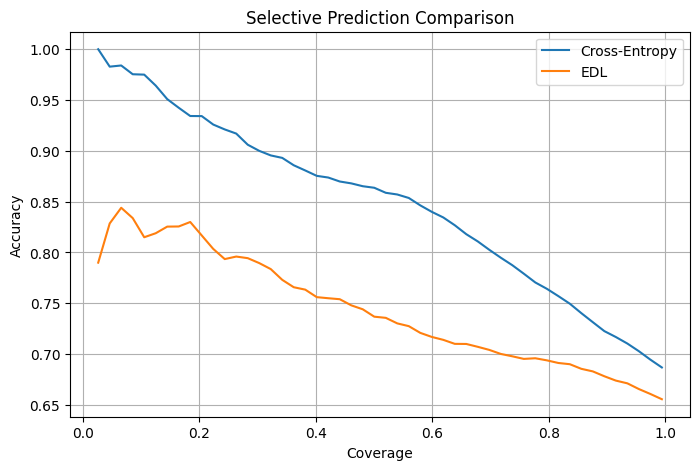

In [52]:
def selective_curve(unc, pred, true):
    idx = np.argsort(unc)

    accs, covs = [], []
    total = len(true)

    for k in range(100, total, total // 50):
        sel = idx[:k]
        acc = np.mean(pred[sel] == true[sel])
        cov = k / total

        accs.append(acc)
        covs.append(cov)

    return covs, accs

cov_ce, acc_ce_curve   = selective_curve(unc_ce, pred_ce, y_test_enc)
cov_edl, acc_edl_curve = selective_curve(unc_edl, pred_edl, y_test_enc)

plt.figure(figsize=(8,5))
plt.plot(cov_ce, acc_ce_curve, label="Cross-Entropy")
plt.plot(cov_edl, acc_edl_curve, label="EDL")
plt.xlabel("Coverage")
plt.ylabel("Accuracy")
plt.title("Selective Prediction Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
print("\n===== FINAL COMPARISON =====")
print(f"EDL Accuracy: {test_acc_edl:.4f}")
print(f"CE  Accuracy: {test_acc_ce:.4f}")


===== FINAL COMPARISON =====
EDL Accuracy: 0.6518
CE  Accuracy: 0.6840


In [54]:
def compute_ece(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(np.max(probs, axis=1), bins) - 1
    ece = 0.0

    for i in range(n_bins):
        bin_mask = bin_indices == i
        if np.sum(bin_mask) > 0:
            bin_accuracy = np.mean(
                np.argmax(probs[bin_mask], axis=1) == labels[bin_mask]
            )
            bin_confidence = np.mean(np.max(probs[bin_mask], axis=1))

            ece += (np.sum(bin_mask) / len(labels)) * abs(
                bin_accuracy - bin_confidence
            )

    return ece

In [57]:
ce_probs = ce_model.predict(X_test)

ece_ce = compute_ece(ce_probs, y_test_enc)
print(f"CE ECE: {ece_ce:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step
CE ECE: 0.1078


In [56]:
evidence = edl_model.predict(X_test)
alpha = evidence + 1.0
edl_probs = alpha / np.sum(alpha, axis=1, keepdims=True)

ece_edl = compute_ece(edl_probs, y_test_enc)
print(f"EDL ECE: {ece_edl:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step
EDL ECE: 0.1368


In [60]:
# CE
ce_conf = np.max(probs_ce, axis=1)
ce_correct = ce_conf[pred_ce == y_test_enc]
ce_wrong = ce_conf[pred_ce != y_test_enc]

print("CE correct confidence:", np.mean(ce_correct))
print("CE wrong confidence:", np.mean(ce_wrong))

# EDL
edl_correct_unc = unc_edl[pred_edl == y_test_enc]
edl_wrong_unc = unc_edl[pred_edl != y_test_enc]

print("EDL correct uncertainty:", np.mean(edl_correct_unc))
print("EDL wrong uncertainty:", np.mean(edl_wrong_unc))

CE correct confidence: 0.85157734
CE wrong confidence: 0.6615729
EDL correct uncertainty: 0.33541676
EDL wrong uncertainty: 0.37480912
